# U-Net Training

Trains the small U-Net on the 14 training images, tracks train/val loss per epoch, evaluates
on the validation set using the exact same precision/recall/F1 method as the classical
baseline, and logs everything to MLflow alongside it for direct comparison.

Given the small dataset, don't expect this to obviously beat the baseline on the first try —
the point of this run is to get the full pipeline working end to end and recorded. Tuning
comes after you can see real numbers, not before.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import mlflow
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import DataLoader

from axonbead_ml.data.dataset import BeadDataset
from axonbead_ml.data.loading import load_annotations_with_condition
from axonbead_ml.data.splits import load_split
from axonbead_ml.models.unet import SmallUNet
from axonbead_ml.training.evaluate import match_points
from axonbead_ml.training.predict import heatmap_to_points

## Step 1: Load data and build DataLoaders

`batch_size=2` is intentionally small — with only 14 training images, larger batches leave
very few gradient updates per epoch. `shuffle=True` on the training loader means each epoch
sees images in a different order, which helps avoid the model latching onto some artifact of
a fixed sequence.

In [60]:
IMAGE_SIZE = 512
SIGMA = 4.0
BATCH_SIZE = 2

raw_dir = Path("../data/raw")
split_df = load_split(Path("../data/processed/splits.csv"))
split_df["path"] = split_df["path"].apply(Path)  # CSV round-trip turns Path back into str
annotations = load_annotations_with_condition(Path("../data/interim/all_annotations.csv"), raw_dir)

train_ds = BeadDataset(split_df, annotations, split="train", image_size=IMAGE_SIZE, sigma=SIGMA)
val_ds = BeadDataset(split_df, annotations, split="val", image_size=IMAGE_SIZE, sigma=SIGMA)
test_ds = BeadDataset(split_df, annotations, split="test", image_size=IMAGE_SIZE, sigma=SIGMA)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False)

print(f"{len(train_ds)} training images, {len(val_ds)} validation images, {len(test_ds)} test images")

42 training images, 9 validation images, 9 test images


## Step 2: Set up model, loss, optimizer

**MSE loss** measures the average squared difference between predicted and target heatmap
pixels — a standard, simple choice for this kind of regression-to-an-image task. One thing to
be aware of: most pixels in the target heatmap are 0 (background), so a model that just
predicts all-zero already gets a fairly low loss. Watch the precision/recall in Step 4 — if
recall stays near zero even as loss drops, that's the sign MSE alone isn't enough and a
weighted loss (penalizing missed bead pixels more) would be the next thing to try, not
something to pre-solve now.

**Adam** optimizer, a standard reliable default for this kind of model — no strong reason to
reach for anything more exotic yet.

In [43]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

LEARNING_RATE = 1e-3
NUM_EPOCHS = 60

model = SmallUNet(in_channels=1, out_channels=1, base_channels=16).to(device)
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)

n_params = sum(p.numel() for p in model.parameters())
print(f"Model has {n_params:,} trainable parameters")

Using device: cpu
Model has 483,153 trainable parameters


## Step 3: Training loop

Each epoch: one full pass over training data (updating weights), then one full pass over
validation data (no weight updates — `model.eval()` and `torch.no_grad()` below turn off
training-only behavior like BatchNorm's running-statistics updates and gradient tracking).
The best checkpoint (lowest validation loss so far) gets saved — this guards against the model
overfitting in later epochs and you accidentally keeping the wrong one.

In [44]:
checkpoint_dir = Path("../checkpoints")
checkpoint_dir.mkdir(exist_ok=True)
best_checkpoint_path = checkpoint_dir / "unet_best.pt"

train_losses, val_losses = [], []
best_val_loss = float("inf")

for epoch in range(1, NUM_EPOCHS + 1):
    model.train()
    running_train_loss = 0.0
    for images, heatmaps, _ in train_loader:
        images, heatmaps = images.to(device), heatmaps.to(device)

        optimizer.zero_grad()
        predictions = model(images)
        loss = criterion(predictions, heatmaps)
        loss.backward()
        optimizer.step()

        running_train_loss += loss.item() * images.size(0)
    train_loss = running_train_loss / len(train_ds)

    model.eval()
    running_val_loss = 0.0
    with torch.no_grad():
        for images, heatmaps, _ in val_loader:
            images, heatmaps = images.to(device), heatmaps.to(device)
            predictions = model(images)
            loss = criterion(predictions, heatmaps)
            running_val_loss += loss.item() * images.size(0)
    val_loss = running_val_loss / len(val_ds)

    train_losses.append(train_loss)
    val_losses.append(val_loss)

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save(model.state_dict(), best_checkpoint_path)

    if epoch % 5 == 0 or epoch == 1:
        print(f"Epoch {epoch:>3}/{NUM_EPOCHS} — train_loss: {train_loss:.5f}, val_loss: {val_loss:.5f}")

print(f"\nBest val_loss: {best_val_loss:.5f} (checkpoint saved to {best_checkpoint_path})")

Epoch   1/60 — train_loss: 0.17020, val_loss: 0.14895
Epoch   5/60 — train_loss: 0.04870, val_loss: 0.04493
Epoch  10/60 — train_loss: 0.01725, val_loss: 0.01604
Epoch  15/60 — train_loss: 0.00808, val_loss: 0.00749
Epoch  20/60 — train_loss: 0.00467, val_loss: 0.00445
Epoch  25/60 — train_loss: 0.00304, val_loss: 0.00291
Epoch  30/60 — train_loss: 0.00217, val_loss: 0.00221
Epoch  35/60 — train_loss: 0.00162, val_loss: 0.00171
Epoch  40/60 — train_loss: 0.00126, val_loss: 0.00144
Epoch  45/60 — train_loss: 0.00101, val_loss: 0.00122
Epoch  50/60 — train_loss: 0.00081, val_loss: 0.00104
Epoch  55/60 — train_loss: 0.00068, val_loss: 0.00091
Epoch  60/60 — train_loss: 0.00055, val_loss: 0.00085

Best val_loss: 0.00082 (checkpoint saved to ..\checkpoints\unet_best.pt)


## Step 4: Plot the loss curves

This is the first real check on whether training worked at all. Watch for: both curves
decreasing (good — learning is happening); train loss dropping while val loss flattens or rises
(overfitting — the small model/dataset size is meant to reduce this risk, but it can still
happen); or both curves staying flat near their starting value (something's wrong — e.g.
learning rate too low, or a bug, not just "needs more epochs").

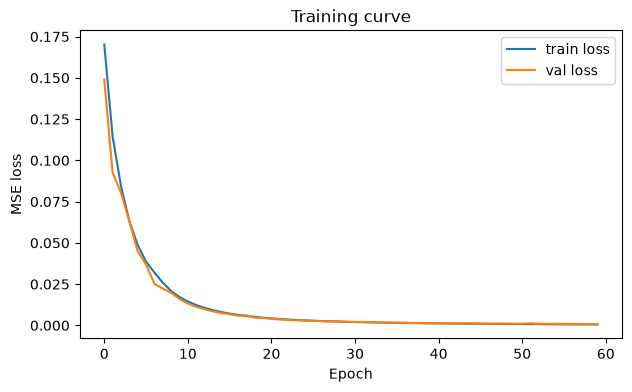

In [45]:
plt.figure(figsize=(7, 4))
plt.plot(train_losses, label="train loss")
plt.plot(val_losses, label="val loss")
plt.xlabel("Epoch")
plt.ylabel("MSE loss")
plt.title("Training curve")
plt.legend()
loss_curve_path = Path("../docs/experiments/unet_v1_loss_curve.png")
plt.savefig(loss_curve_path, dpi=100, bbox_inches="tight")
plt.show()

**Takeaway:** _fill in once you see the real curve — did it converge, and does val loss track
train loss reasonably closely?_

In [58]:
PEAK_THRESHOLD = 0.25
MIN_PEAK_DISTANCE = 5
MAX_MATCH_DISTANCE = 15.0  # same value used for the baseline, for a fair comparison

model.load_state_dict(torch.load(best_checkpoint_path, map_location=device))
model.eval()

results = []
scale = IMAGE_SIZE / 1024  # heatmap/prediction coords need to map back to original image scale

with torch.no_grad():
    for images, heatmaps, image_names in val_loader:
        images = images.to(device)
        predictions = model(images).cpu().numpy()

        for i, image_name in enumerate(image_names):
            pred_heatmap = predictions[i, 0]
            predicted_points = heatmap_to_points(
                pred_heatmap, threshold=PEAK_THRESHOLD, min_distance=MIN_PEAK_DISTANCE
            )
            predicted_points_original_scale = predicted_points / scale

            ground_truth = annotations.loc[annotations["image"] == image_name, ["y", "x"]].values
            condition = split_df.loc[split_df["image"] == image_name, "condition"].iloc[0]

            metrics = match_points(predicted_points_original_scale, ground_truth, max_distance=MAX_MATCH_DISTANCE)
            metrics["image"] = image_name
            metrics["condition"] = condition
            results.append(metrics)

results_df = pd.DataFrame(results)
results_df

,true_positives,false_positives,false_negatives,precision,recall,f1,image,condition
0,1,5,0,0.166667,1.000000,0.285714,NI231117_SMI31-488_20x_HCl_03.czi,control
1,2,1,0,0.666667,1.000000,0.800000,NI231117_SMI31-488_20x_HCl_05.czi,control
2,0,1,1,0.000000,0.000000,0.000000,NI240119_SMI31-488_20x_NT_03.czi,control
3,6,2,7,0.750000,0.461538,0.571429,NI240119_SMI31-488_20x_DMSO_01.czi,high_beads
4,16,5,10,0.761905,0.615385,0.680851,NI240119_SMI31-488_20x_DMSO_05.czi,high_beads
5,17,5,9,0.772727,0.653846,0.708333,NI240119_SMI31-488_20x_Glut_02.czi,high_beads
6,10,3,8,0.769231,0.555556,0.645161,NI231117_SMI31-488_20x_LiCl_03.czi,low_beads
7,8,1,4,0.888889,0.666667,0.761905,NI231117_SMI31-488_20x_LiCl_04.czi,low_beads
8,11,4,8,0.733333,0.578947,0.647059,NI240119_SMI31-488_20x_CHIR_02.czi,low_beads


## Step 5: Evaluate on validation images — precision/recall/F1

Load the best checkpoint (not necessarily the last epoch's weights), predict a heatmap per
validation image, convert each prediction back to points with `heatmap_to_points`, and score
with the identical `match_points` function used for the classical baseline. This is what makes
"did the U-Net beat the baseline" a real, apples-to-apples comparison rather than a guess.

In [59]:
overall_tp = results_df["true_positives"].sum()
overall_fp = results_df["false_positives"].sum()
overall_fn = results_df["false_negatives"].sum()
overall_precision = overall_tp / (overall_tp + overall_fp) if (overall_tp + overall_fp) else 0.0
overall_recall = overall_tp / (overall_tp + overall_fn) if (overall_tp + overall_fn) else 0.0
overall_f1 = (
    2 * overall_precision * overall_recall / (overall_precision + overall_recall)
    if (overall_precision + overall_recall) else 0.0
)
print(f"U-Net (val set) — precision: {overall_precision:.3f}, recall: {overall_recall:.3f}, f1: {overall_f1:.3f}")
print("\nCompare to classical baseline (all 60 images) — precision: 0.237, recall: 0.607, f1: 0.341")
print("\nBy condition:")
results_df.groupby("condition")[["precision", "recall", "f1"]].mean().round(3)

U-Net (val set) — precision: 0.724, recall: 0.602, f1: 0.657

Compare to classical baseline (all 60 images) — precision: 0.237, recall: 0.607, f1: 0.341

By condition:


,precision,recall,f1
condition,,,
control,0.278,0.667,0.362
high_beads,0.762,0.577,0.654
low_beads,0.797,0.600,0.685


**Takeaway:** _fill in — does this beat the baseline? Remember val here is only ~9 images
(3 per condition), so treat this as a first read, not a final verdict — the real held-out check
is the untouched test set, saved for later once you've settled on a model configuration through
iteration on val._

## Step 6: Log this run to MLflow

Same experiment as the baseline (`axonbead-ml`), so both show up together in the UI for direct
comparison.

In [57]:
mlflow.set_tracking_uri(f"sqlite:///{Path('../mlflow.db').resolve().as_posix()}")
mlflow.set_experiment("axonbead-ml")

with mlflow.start_run(run_name="unet_v1"):
    mlflow.log_param("model_type", "unet")
    mlflow.log_param("base_channels", 16)
    mlflow.log_param("image_size", IMAGE_SIZE)
    mlflow.log_param("sigma", SIGMA)
    mlflow.log_param("batch_size", BATCH_SIZE)
    mlflow.log_param("learning_rate", LEARNING_RATE)
    mlflow.log_param("num_epochs", NUM_EPOCHS)
    mlflow.log_param("peak_threshold", PEAK_THRESHOLD)
    mlflow.log_param("min_peak_distance", MIN_PEAK_DISTANCE)
    mlflow.log_param("max_match_distance", MAX_MATCH_DISTANCE)

    for epoch, (tl, vl) in enumerate(zip(train_losses, val_losses), start=1):
        mlflow.log_metric("train_loss", tl, step=epoch)
        mlflow.log_metric("val_loss", vl, step=epoch)

    mlflow.log_metric("precision", overall_precision)
    mlflow.log_metric("recall", overall_recall)
    mlflow.log_metric("f1", overall_f1)
    for condition, group in results_df.groupby("condition"):
        mlflow.log_metric(f"f1_{condition}", group["f1"].mean())

    mlflow.log_artifact(str(loss_curve_path))
    mlflow.log_artifact(str(best_checkpoint_path))

    results_path = Path("../docs/experiments/unet_v1_val_results.csv")
    results_df.to_csv(results_path, index=False)
    mlflow.log_artifact(str(results_path))

    print(f"Run logged. Run ID: {mlflow.active_run().info.run_id}")

Run logged. Run ID: 81fbb6218943452e9421a8482a702a60


## Next

Run `mlflow ui --backend-store-uri sqlite:///mlflow.db` from the project root and compare
`baseline_classical_otsu` (wait — that run's name was actually the manual-threshold version;
check the params in the UI to confirm) against `unet_v1` side by side.

If results look promising but not great: try more epochs, tuning `PEAK_THRESHOLD`, or a
weighted loss. If the model badly underperforms (e.g. near-zero recall), that's the signal to
revisit the MSE-vs-class-imbalance issue flagged in Step 2 before tuning anything else.

Once you're satisfied with val performance, the untouched **test set** is the final, honest
check — evaluate on it exactly once, ideally after you've stopped iterating.

## Step 7: Evaluate on test images — precision/recall/F1¶

Once parameters are tuned base on the validation dataset, evaluate once on the test images.

In [61]:
PEAK_THRESHOLD = 0.25
MIN_PEAK_DISTANCE = 5
MAX_MATCH_DISTANCE = 15.0  # same value used for the baseline, for a fair comparison

import datetime
mtime = best_checkpoint_path.stat().st_mtime
print(f"Checkpoint last modified: {datetime.datetime.fromtimestamp(mtime)}")

model.load_state_dict(torch.load(best_checkpoint_path, map_location=device))
model.eval()

results = []
scale = IMAGE_SIZE / 1024  # heatmap/prediction coords need to map back to original image scale

with torch.no_grad():
    for images, heatmaps, image_names in test_loader:
        images = images.to(device)
        predictions = model(images).cpu().numpy()

        for i, image_name in enumerate(image_names):
            pred_heatmap = predictions[i, 0]
            predicted_points = heatmap_to_points(
                pred_heatmap, threshold=PEAK_THRESHOLD, min_distance=MIN_PEAK_DISTANCE
            )
            predicted_points_original_scale = predicted_points / scale

            ground_truth = annotations.loc[annotations["image"] == image_name, ["y", "x"]].values
            condition = split_df.loc[split_df["image"] == image_name, "condition"].iloc[0]

            metrics = match_points(predicted_points_original_scale, ground_truth, max_distance=MAX_MATCH_DISTANCE)
            metrics["image"] = image_name
            metrics["condition"] = condition
            results.append(metrics)

results_df = pd.DataFrame(results)
results_df

Checkpoint last modified: 2026-08-16 16:02:18.924771


,true_positives,false_positives,false_negatives,precision,recall,f1,image,condition
0,1,0,2,1.000000,0.333333,0.500000,NI231117_SMI31-488_20x_HCl_02.czi,control
1,3,0,0,1.000000,1.000000,1.000000,NI231117_SMI31-488_20x_NT_04.czi,control
2,4,7,0,0.363636,1.000000,0.533333,NI240119_SMI31-488_20x_HCl_04.czi,control
3,10,6,6,0.625000,0.625000,0.625000,NI231117_SMI31-488_20x_DMSOx1_04.czi,high_beads
4,8,3,9,0.727273,0.470588,0.571429,NI240119_SMI31-488_20x_DMSO_04.czi,high_beads
5,18,5,9,0.782609,0.666667,0.720000,NI240119_SMI31-488_20x_Glut_03.czi,high_beads
6,9,10,7,0.473684,0.562500,0.514286,NI231117_SMI31-488_20x_LiCl_01.czi,low_beads
7,13,7,5,0.650000,0.722222,0.684211,NI231117_SMI31-488_20x_LiCl_05.czi,low_beads
8,5,2,6,0.714286,0.454545,0.555556,NI240119_SMI31-488_20x_Pio_02.czi,low_beads


In [62]:
overall_tp = results_df["true_positives"].sum()
overall_fp = results_df["false_positives"].sum()
overall_fn = results_df["false_negatives"].sum()
overall_precision = overall_tp / (overall_tp + overall_fp) if (overall_tp + overall_fp) else 0.0
overall_recall = overall_tp / (overall_tp + overall_fn) if (overall_tp + overall_fn) else 0.0
overall_f1 = (
    2 * overall_precision * overall_recall / (overall_precision + overall_recall)
    if (overall_precision + overall_recall) else 0.0
)
print(f"U-Net (val set) — precision: {overall_precision:.3f}, recall: {overall_recall:.3f}, f1: {overall_f1:.3f}")
print("\nCompare to classical baseline (all 60 images) — precision: 0.237, recall: 0.607, f1: 0.341")
print("\nBy condition:")
results_df.groupby("condition")[["precision", "recall", "f1"]].mean().round(3)

U-Net (val set) — precision: 0.640, recall: 0.617, f1: 0.628

Compare to classical baseline (all 60 images) — precision: 0.237, recall: 0.607, f1: 0.341

By condition:


,precision,recall,f1
condition,,,
control,0.788,0.778,0.678
high_beads,0.712,0.587,0.639
low_beads,0.613,0.580,0.585


## Step 8: Log as its own MLflow run 

In [63]:
mlflow.set_tracking_uri(f"sqlite:///{Path('../mlflow.db').resolve().as_posix()}")
mlflow.set_experiment("axonbead-ml")

with mlflow.start_run(run_name="unet_v1_test_final"):
    mlflow.log_param("model_type", "unet")
    mlflow.log_param("base_channels", 16)
    mlflow.log_param("image_size", IMAGE_SIZE)
    mlflow.log_param("sigma", SIGMA)
    mlflow.log_param("batch_size", BATCH_SIZE)
    mlflow.log_param("learning_rate", LEARNING_RATE)
    mlflow.log_param("num_epochs", 60)
    mlflow.log_param("peak_threshold", 0.25)
    mlflow.log_param("min_peak_distance", MIN_PEAK_DISTANCE)
    mlflow.log_param("max_match_distance", MAX_MATCH_DISTANCE)
    mlflow.log_param("evaluated_on", "test_set_final")
    mlflow.log_param("checkpoint_used", str(best_checkpoint_path))

    mlflow.log_metric("precision", overall_precision)
    mlflow.log_metric("recall", overall_recall)
    mlflow.log_metric("f1", overall_f1)
    for condition, group in results_df.groupby("condition"):
        mlflow.log_metric(f"f1_{condition}", group["f1"].mean())

    results_path = Path("../docs/experiments/unet_v1_val_results.csv")
    results_df.to_csv(results_path, index=False)
    mlflow.log_artifact(str(results_path))

    print(f"Run logged. Run ID: {mlflow.active_run().info.run_id}")

Run logged. Run ID: 4da58132ce7f4a0e8ab771dfc9cac62e
